In [1]:
# =======================================================
# MASTER NOTEBOOK #6: RESNET50V2 + XGBOOST
# =======================================================

# --- PHASE 1: SETUP & SPLIT ---
!pip install split-folders
from google.colab import drive
import zipfile, os, shutil, splitfolders

drive.mount('/content/drive')
zip_path = '/content/drive/MyDrive/Brinjal_Final_Dataset.zip'
extract_path = '/content/dataset_resnet_xgb'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

base_extracted_dir = extract_path
unhealthy_dir = os.path.join(base_extracted_dir, 'Unhealthy_Leaves')

if os.path.exists(unhealthy_dir):
    for folder_name in os.listdir(unhealthy_dir):
        shutil.move(os.path.join(unhealthy_dir, folder_name), os.path.join(base_extracted_dir, folder_name))
    os.rmdir(unhealthy_dir)

output_dir = '/content/split_dataset_resnet_xgb'
splitfolders.ratio(base_extracted_dir, output=output_dir, seed=42, ratio=(0.7, 0.15, 0.15), group_prefix=None)
print("Data splitting complete.")

Mounted at /content/drive


Copying files: 850 files [00:00, 6032.54 files/s]

Data splitting complete.


In [2]:
# --- PHASE 2: GENERATORS (NO SHUFFLE) ---
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet_v2 import preprocess_input

IMG_WIDTH, IMG_HEIGHT = 224, 224
BATCH_SIZE = 32

datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# Shuffle MUST be False so XGBoost labels align perfectly with extracted features
train_generator = datagen.flow_from_directory(
    '/content/split_dataset_resnet_xgb/train', target_size=(IMG_WIDTH, IMG_HEIGHT), batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)
test_generator = datagen.flow_from_directory(
    '/content/split_dataset_resnet_xgb/test', target_size=(IMG_WIDTH, IMG_HEIGHT), batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)

class_labels = list(train_generator.class_indices.keys())
print("Classes identified:", class_labels)

Found 595 images belonging to 3 classes.
Found 128 images belonging to 3 classes.
Classes identified: ['Healthy_Leaves', 'Little_Leaf', 'Phomopsis_Blight']


In [3]:
# --- PHASE 3: RESNET50V2 FEATURE EXTRACTION ---
from tensorflow.keras.applications import ResNet50V2
import numpy as np

# Load ResNet50V2 strictly as a Feature Extractor (pooling='avg' flattens the output to 2048 dimensions)
feature_extractor = ResNet50V2(weights='imagenet', include_top=False, input_shape=(IMG_WIDTH, IMG_HEIGHT, 3), pooling='avg')

print("Extracting Train Features via ResNet50V2...")
train_generator.reset()
X_train_features = feature_extractor.predict(train_generator, verbose=1)
y_train = train_generator.classes

print("Extracting Test Features via ResNet50V2...")
test_generator.reset()
X_test_features = feature_extractor.predict(test_generator, verbose=1)
y_test = test_generator.classes

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Extracting Train Features via ResNet50V2...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


19/19 ━━━━━━━━━━━━━━━━━━━━ 103s 5s/step
Extracting Test Features via ResNet50V2...
4/4 ━━━━━━━━━━━━━━━━━━━━ 22s 5s/step


In [4]:
# --- PHASE 4: XGBOOST CLASSIFIER ---
import xgboost as xgb
from sklearn.utils.class_weight import compute_sample_weight

# Calculate weights to penalize the algorithm if it ignores minority classes
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# Initialize XGBoost. Multi:softprob is essential for the ROC curve later.
xgb_model = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    max_depth=6,           # Deep enough to catch complex interactions
    learning_rate=0.05,    # Slower learning rate for maximum precision
    n_estimators=400,      # 400 boosting rounds
    random_state=42
)

print("Training XGBoost Classifier...")
xgb_model.fit(X_train_features, y_train, sample_weight=sample_weights)
print("Training Complete!")

Training XGBoost Classifier...
Training Complete!



Test Accuracy: 90.62%

--- Classification Report ---
                   precision    recall  f1-score   support

  Healthy_Leaves       0.95      0.98      0.97        60
     Little_Leaf       0.95      0.67      0.78        30
Phomopsis_Blight       0.82      0.97      0.89        38

        accuracy                           0.91       128
       macro avg       0.91      0.87      0.88       128
    weighted avg       0.91      0.91      0.90       128



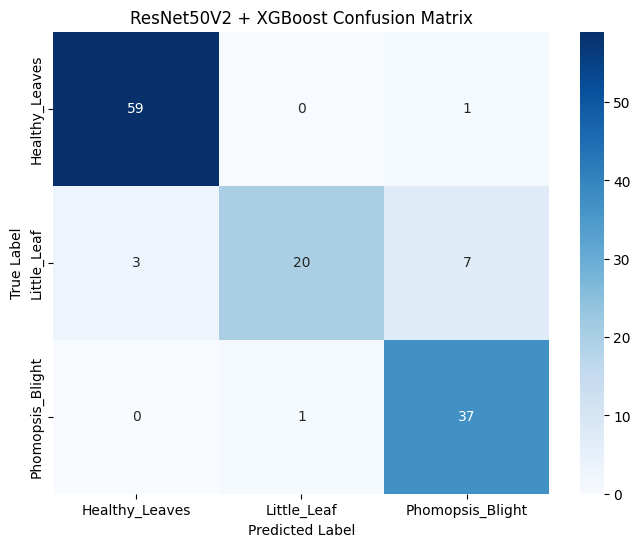

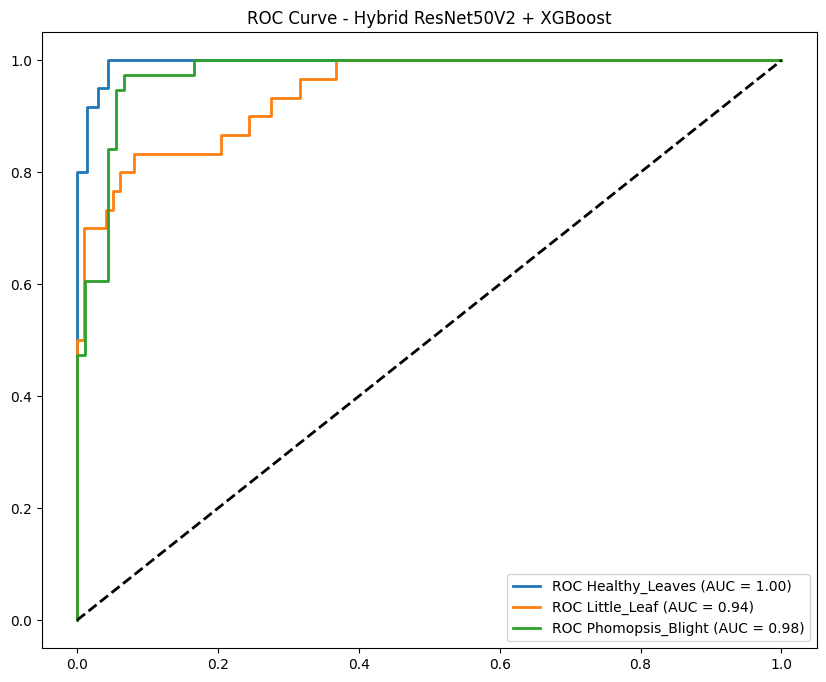

In [5]:
# --- PHASE 5: EVALUATION & ROC ---
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, accuracy_score
from sklearn.preprocessing import label_binarize

# Get Predictions
Y_pred_prob = xgb_model.predict_proba(X_test_features)
y_pred_classes = np.argmax(Y_pred_prob, axis=1)

print(f"\nTest Accuracy: {accuracy_score(y_test, y_pred_classes) * 100:.2f}%")
print("\n--- Classification Report ---\n", classification_report(y_test, y_pred_classes, target_names=class_labels))

cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('ResNet50V2 + XGBoost Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
plt.figure(figsize=(10, 8))
for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], Y_pred_prob[:, i])
    plt.plot(fpr, tpr, lw=2, label=f'ROC {class_labels[i]} (AUC = {auc(fpr, tpr):.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.title('ROC Curve - Hybrid ResNet50V2 + XGBoost')
plt.legend(loc="lower right")
plt.show()

In [6]:
# --- PHASE 6: EXPORT STATS ---
from google.colab import files
import pickle

# 1. Save deep learning feature extractor (.h5)
feature_extractor.save('resnet50v2_extractor_3class.h5')
files.download('resnet50v2_extractor_3class.h5')

# 2. Save Machine Learning Classifier (.json for XGBoost)
xgb_model.save_model('xgb_classifier_3class.json')
files.download('xgb_classifier_3class.json')

# 3. Bundle the exact predictions and labels for statistical testing
hybrid_xgb_test_results = {
    'model_name': 'ResNet50V2_XGBoost',
    'y_true': y_test,
    'y_pred_prob': Y_pred_prob,
    'y_pred_classes': y_pred_classes,
    'class_labels': class_labels
}

with open('hybrid_xgb_test_results.pkl', 'wb') as f:
    pickle.dump(hybrid_xgb_test_results, f)
files.download('hybrid_xgb_test_results.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>